## Model 2: Hierarchical table model (Stan)

**Idea:** same covariates as Model 1, but team **skill varies by season** (`skill[season, team]`).  
Forecast uses skills and covariates from the **last training season** (2425 for backtest).

**Backtest:** tables through 2024/25 → predict table 2025/26.

$$\text{Pts}_{s,t} \sim t_{\nu}\big(\alpha + \beta \cdot \text{skill}_{s,t} + \gamma^\top x_{s,t},\; \sigma_{\text{pts}}\big)$$

with $x$ = (`sot_diff_pg`, `pts_lag1`, `ppg_last10`, z-scored).  
Student-$t$ with $\nu=5$ fixed; $\sigma_{\text{skill}}$ — spread of teams within a season.


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
from cmdstanpy import CmdStanModel

import importlib
import helping_functions as hf
importlib.reload(hf)

from helping_functions import (
    load_matches,
    load_season_tables,
    prepare_table_stan_hierarchical,
    build_forecast_features,
    compute_table,
    predict_table,
    teams_in_season,
    STUDENT_T_NU,
    BACKTEST_TRAIN_SEASONS,
    BACKTEST_TEST_SEASON,
)


In [11]:
matches = load_matches()
TRAIN_SEASONS = BACKTEST_TRAIN_SEASONS
TEST_SEASON = BACKTEST_TEST_SEASON
LAST_TRAIN_SEASON = "2425"

tables = load_season_tables(matches, TRAIN_SEASONS)
stan_data, team_to_idx, train_teams, season_to_idx, feature_stats = (
    prepare_table_stan_hierarchical(tables, TRAIN_SEASONS)
)
stan_data["nu"] = STUDENT_T_NU
test_teams = sorted(teams_in_season(matches, TEST_SEASON))
last_season_idx = season_to_idx[LAST_TRAIN_SEASON]

print(f"Rows: {stan_data['N']}, seasons S={stan_data['S']}, teams T={stan_data['T']}")
print(f"Forecast uses season {LAST_TRAIN_SEASON} (index {last_season_idx})")
print(tables[['sot_diff_pg', 'pts_lag1', 'ppg_last10']].describe().round(2))


Rows: 320, seasons S=16, teams T=42
Forecast uses season 2425 (index 16)
       sot_diff_pg  pts_lag1  ppg_last10
count       320.00    320.00      320.00
mean          0.00     45.02        1.39
std           1.98     26.80        0.59
min          -4.66      0.00        0.00
25%          -1.38     38.00        0.90
50%          -0.39     47.00        1.40
75%           1.24     63.25        1.80
max           6.03    100.00        3.00


### Prior selection (Model 2)

| Parameter | Prior | Rationale |
|-----------|-------|-----------|
| `intercept`, `beta_pts`, `sigma_pts` | as Model 1 | Student-$t$ ($\nu=5$) |
| `sigma_skill` | $\mathcal{N}(0, 0.4)\,T[0,]$ | Season-to-season team spread on skill scale |

Prior predictive: same check as Model 1 on pooled points (see notebook 02).


In [12]:
model = CmdStanModel(stan_file="stan/table_hierarchical.stan")
fit = model.sample(
    data=stan_data,
    seed=42,
    chains=4,
    parallel_chains=4,
    iter_warmup=1500,
    iter_sampling=1500,
    adapt_delta=0.99,
    show_progress=True,
)
print(fit.diagnose())


15:40:02 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

15:40:27 - cmdstanpy - INFO - CmdStan done processing.
15:40:27 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'table_hierarchical.stan', line 53, column 4 to column 42)
	Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'table_hierarchical.stan', line 53, column 4 to column 42)
Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'table_hierarchical.stan', line 53, column 4 to column 42)
	Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'table_hierarchical.stan', line 53, column 4 to column 42)
	Exception: student_t_lpdf: Scale parameter is 0, but must be positive finite! (in 'table_hierarchical.stan', line 53, column 4 to column 42)
Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'table_hierarchical.stan', line 53, column 4 to column 42)
	Exception: student_


Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
The E-BFMI, 0.30, is below the nominal threshold of 0.30 which suggests that HMC may have trouble exploring the target distribution.
If possible, try to reparameterize the model.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete.



In [13]:
fit.summary().loc[
    ["intercept", "beta_pts", "beta_sot", "beta_lag", "beta_form", "sigma_pts", "sigma_skill", "lp__"]
]

idata = az.from_cmdstanpy(fit)
print(az.summary(idata, var_names=[
    "intercept", "beta_pts", "beta_sot", "beta_lag", "beta_form", "sigma_pts", "sigma_skill"
]))


               mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
intercept    52.213  0.403  51.463   52.968      0.006    0.006    5159.0   
beta_pts     19.006  8.348   4.172   33.869      0.126    0.113    3599.0   
beta_sot      9.327  0.647   8.070   10.508      0.009    0.007    5697.0   
beta_lag      1.323  0.360   0.661    2.008      0.004    0.005    9260.0   
beta_form     7.112  0.620   5.975    8.305      0.008    0.007    6106.0   
sigma_pts     5.489  0.751   4.159    6.881      0.049    0.019     239.0   
sigma_skill   0.236  0.147   0.004    0.503      0.005    0.003     606.0   

             ess_tail  r_hat  
intercept      4467.0   1.00  
beta_pts       2179.0   1.00  
beta_sot       4629.0   1.00  
beta_lag       4450.0   1.00  
beta_form      4517.0   1.00  
sigma_pts       600.0   1.01  
sigma_skill     695.0   1.01  


In [14]:
s_idx = last_season_idx - 1
skill_last = fit.stan_variable("skill")[:, s_idx, :].mean(axis=0)
idx_to_team = {i: t for t, i in team_to_idx.items()}

pd.DataFrame({
    "team": [idx_to_team[j+1] for j in range(len(skill_last))],
    "skill": skill_last,
}).sort_values("skill", ascending=False).head(10)


,team,skill
27,Nott'm Forest,0.231938
20,Liverpool,0.229358
25,Newcastle,0.117830
0,Arsenal,0.100845
14,Fulham,0.053222
6,Bournemouth,0.052796
7,Brentford,0.048694
8,Brighton,0.040996
11,Chelsea,0.021328
39,West Ham,0.011879


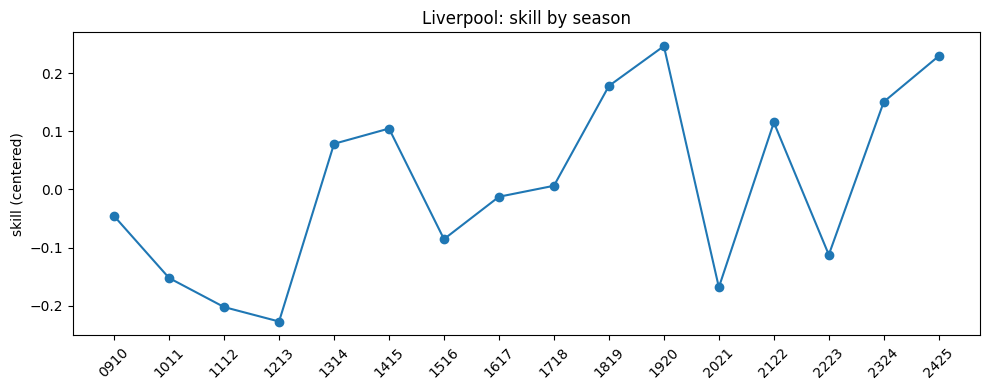

In [15]:
example_team = "Liverpool"
if example_team in team_to_idx:
    j = team_to_idx[example_team] - 1
    skill_ts = fit.stan_variable("skill")[:, :, j].mean(axis=0)
    seasons = list(season_to_idx.keys())
    plt.figure(figsize=(10, 4))
    plt.plot(seasons, skill_ts, marker="o")
    plt.xticks(rotation=45)
    plt.ylabel("skill (centered)")
    plt.title(f"{example_team}: skill by season")
    plt.tight_layout()
    plt.show()


### Predict table 2025/26


In [16]:
forecast_features = build_forecast_features(
    matches, LAST_TRAIN_SEASON, test_teams, TRAIN_SEASONS, feature_stats
)

pred_table = predict_table(
    fit,
    test_teams,
    team_to_idx,
    model="hierarchical",
    last_season_index=last_season_idx,
    team_features=forecast_features,
    n_sims=500,
    seed=42,
)

actual = compute_table(matches, TEST_SEASON)[["team", "position", "Pts"]]
actual = actual.rename(columns={"position": "pos_actual", "Pts": "pts_actual"})

comparison = pred_table.merge(actual, on="team", how="left")
comparison["pos_error"] = comparison["pos_median"] - comparison["pos_actual"]
comparison.sort_values("pos_actual")


,team,pos_median,pos_mean,pts_median,pts_mean,pos_actual,pts_actual,pos_error
2,Arsenal,4.0,4.134,69.968275,70.048624,1,85,3.0
0,Man City,2.0,2.728,75.167325,75.395325,2,78,0.0
17,Man United,16.0,15.448,46.614680,46.871255,3,71,13.0
4,Aston Villa,5.0,5.484,66.948925,66.616548,4,65,1.0
1,Liverpool,2.0,3.262,73.125064,73.069204,5,60,-3.0
7,Bournemouth,11.0,11.292,54.803077,54.902736,6,57,5.0
11,Sunderland,13.0,12.528,52.458541,52.518625,7,54,6.0
6,Brighton,8.0,8.720,59.688331,59.382825,8,53,0.0
10,Brentford,12.0,11.684,54.261697,54.228353,9,53,3.0
3,Chelsea,4.0,4.718,68.301161,68.343742,10,52,-6.0


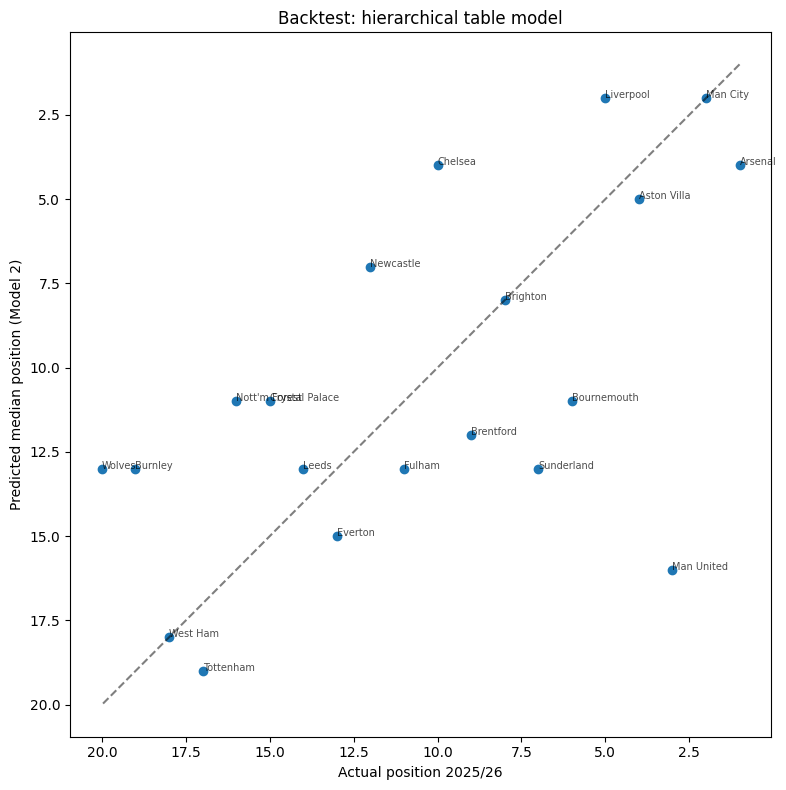

MAE position: 3.70


In [17]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(comparison["pos_actual"], comparison["pos_median"])
for _, r in comparison.iterrows():
    ax.annotate(r["team"], (r["pos_actual"], r["pos_median"]), fontsize=7, alpha=0.7)
ax.plot([1, 20], [1, 20], "k--", alpha=0.5)
ax.set_xlabel("Actual position 2025/26")
ax.set_ylabel("Predicted median position (Model 2)")
ax.set_title("Backtest: hierarchical table model")
ax.invert_xaxis()
ax.invert_yaxis()
plt.tight_layout()
plt.show()
print(f"MAE position: {comparison['pos_error'].abs().mean():.2f}")


### WAIC / LOO

Student-$t$ likelihood should lower Pareto $k$ for outlier team-seasons vs. Normal.  
Check `pareto_k`: values $\leq 0.7$ are reliable; $> 0.7$ = influential points.


In [19]:
idata = az.from_cmdstanpy(fit)
print(az.waic(idata))
loo = az.loo(idata, pointwise=True)
print(loo)

k = loo.pareto_k.values
n_good = int((k <= 0.7).sum())
n_bad = int(((k > 0.7) & (k <= 1)).sum())
n_very_bad = int((k > 1).sum())
print(f"\nPareto k: good (≤0.7) {n_good}/{len(k)} ({100 * n_good / len(k):.1f}%)")
print(f"           bad (0.7–1] {n_bad}, very bad (>1) {n_very_bad}")


/usr/local/lib/python3.11/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


Computed from 6000 posterior samples and 320 observations log-likelihood matrix.

          Estimate       SE
elpd_waic -1098.53    12.33
p_waic       94.48        -

There has been a warning during the calculation. Please check the results.
Computed from 6000 posterior samples and 320 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -1103.00    12.41
p_loo       98.95        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      319   99.7%
   (0.70, 1]   (bad)         1    0.3%
   (1, Inf)   (very bad)    0    0.0%


Pareto k: good (≤0.7) 319/320 (99.7%)
           bad (0.7–1] 1, very bad (>1) 0


/usr/local/lib/python3.11/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
